# Trip-time descriptive statistics

Descriptive statistics for observed trip times along a single shape, across every service date in the by-date vehicle-position dataset. This is a precursor to the delay breakdown (MIT thesis §3.4.5): characterizing the distribution of running times and splitting day vs night trips (night ≈ free-flow baseline) before decomposing delay into components.

A *trip* here is one `TRIP_KEY` within one service date; *trip time* is the observed span of its GPS pings (`max - min` of `event_time_datetime`).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from _data_loaders import get_culver_city_vehicle_positions, list_available_service_dates

## Configuration

`SHAPE_KEY` selects the route/shape (start with `"105"`). `NIGHT_START_HOUR` is the local hour (24h) at/after which a trip's *start* counts as night. `MIN_TRIP_MINUTES` drops degenerate trips (GPS fragments / deadheads) from the stats and histograms; set to `0` to keep everything.

In [9]:
SHAPE_KEY = "105"
NIGHT_START_HOUR = 20  # trips starting at/after 22:00 are "night"
MIN_TRIP_MINUTES = 5   # exclude shorter trips as fragments/deadheads

## Load all service dates

Read each per-date geoparquet for the selected shape and stack them, tagging every ping with its `service_date`.

In [10]:
service_dates = list_available_service_dates()
print(f"{len(service_dates)} service dates: {service_dates[0]} … {service_dates[-1]}")

per_date_positions = [
    get_culver_city_vehicle_positions([SHAPE_KEY], service_date).assign(service_date=service_date)
    for service_date in service_dates
]
vp_all = pd.concat(per_date_positions, ignore_index=True)
print(f"{len(vp_all):,} vehicle-position rows for shape {SHAPE_KEY}")

22 service dates: 2026-01-27 … 2026-02-17
293,339 vehicle-position rows for shape 105


## Per-trip table

Collapse pings to one row per (`service_date`, `TRIP_KEY`): start, end, duration, ping count, and the day/night period from the start time.

In [11]:
trip_table = (
    vp_all.groupby(["service_date", "TRIP_KEY"], dropna=True)
    .agg(
        trip_start=("event_time_datetime", "min"),
        trip_end=("event_time_datetime", "max"),
        n_pings=("event_time_datetime", "size"),
    )
    .reset_index()
)

trip_table["duration_min"] = (
    trip_table["trip_end"] - trip_table["trip_start"]
).dt.total_seconds() / 60
trip_table["start_hour"] = trip_table["trip_start"].dt.hour
trip_table["period"] = np.where(
    trip_table["start_hour"] >= NIGHT_START_HOUR, "night", "day"
)

print(f"{len(trip_table)} trips total")
trip_table.head()

774 trips total


,service_date,TRIP_KEY,trip_start,trip_end,n_pings,duration_min,start_hour,period
0,2026-01-31,1016.0,2026-01-31 14:13:04,2026-01-31 15:03:12,254,50.133333,14,day
1,2026-01-31,1050.0,2026-01-31 21:23:07,2026-01-31 22:11:48,583,48.683333,21,night
2,2026-01-31,1053.0,2026-01-31 10:33:04,2026-01-31 11:23:09,280,50.083333,10,day
3,2026-01-31,1068.0,2026-01-31 14:35:06,2026-01-31 15:30:58,301,55.866667,14,day
4,2026-01-31,1089.0,2026-01-31 15:41:16,2026-01-31 16:31:44,325,50.466667,15,day


## Data quality: short trips

Degenerate trips (very short observed spans) are likely GPS fragments or deadheads rather than full revenue trips. Report them, then keep only trips at least `MIN_TRIP_MINUTES` long for the stats below.

In [12]:
short_trips = trip_table[trip_table["duration_min"] < MIN_TRIP_MINUTES]
print(f"{len(short_trips)} of {len(trip_table)} trips shorter than {MIN_TRIP_MINUTES} min (excluded)")

trips = trip_table[trip_table["duration_min"] >= MIN_TRIP_MINUTES].copy()
print(f"{len(trips)} trips kept")

10 of 774 trips shorter than 5 min (excluded)
764 trips kept


## Number of trips per period

In [13]:
print("Trips per period (all dates):")
print(trips["period"].value_counts())

print("\nTrips per period per service date:")
trips.groupby(["service_date", "period"]).size().unstack(fill_value=0)

Trips per period (all dates):
period
day      676
night     88
Name: count, dtype: int64

Trips per period per service date:


period,day,night
service_date,,
2026-01-31,37,8
2026-02-01,36,8
2026-02-02,42,4
2026-02-03,43,4
2026-02-04,48,4
2026-02-05,48,4
2026-02-06,41,4
2026-02-07,34,8
2026-02-08,29,7


## Trip-time descriptive statistics by period

In [7]:
trips.groupby("period")["duration_min"].describe()

,count,mean,std,min,25%,50%,75%,max
period,,,,,,,,
day,751.0,46.941145,5.192638,19.866667,44.391667,47.083333,50.016667,74.750000
night,13.0,42.676923,3.361000,35.333333,42.350000,43.583333,43.766667,47.733333


## Histogram of trip times: day vs night

Shared bins so the two periods are directly comparable. Night trips are sparse (few late departures per day), so counts differ substantially.

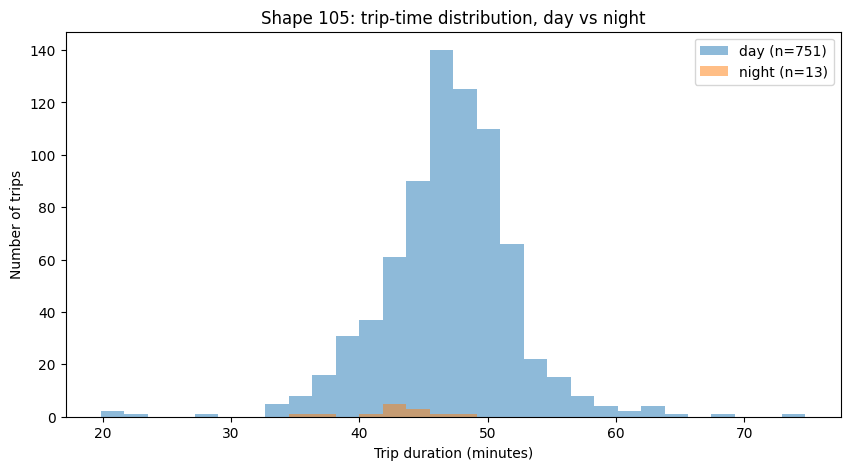

In [8]:
bins = np.histogram_bin_edges(trips["duration_min"], bins=30)

fig, ax = plt.subplots(figsize=(10, 5))
for period, color in [("day", "tab:blue"), ("night", "tab:orange")]:
    durations = trips.loc[trips["period"] == period, "duration_min"]
    ax.hist(durations, bins=bins, alpha=0.5, color=color, label=f"{period} (n={len(durations)})")

ax.set_xlabel("Trip duration (minutes)")
ax.set_ylabel("Number of trips")
ax.set_title(f"Shape {SHAPE_KEY}: trip-time distribution, day vs night")
ax.legend()
plt.show()